In [167]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from pathlib import Path

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

# グラフ全体のフォント設定
# plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
# plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
# plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
# plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
# plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
# plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
# plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
# plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
# plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
# plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [168]:
network_type = "TwoRR"
N = 10000
z = 6
z_bar = 6
cMin = 0.1
file_type = "final"
ini_type = "nonbfs"
index_cols = [] if file_type == "final" else ["time"]
index_cols.extend(["itr", "lambda", "mu", "rho", "c"])

In [169]:
c_list = {0.1,2.0}

In [170]:
sim_results=[[] for _ in range(len(c_list))]
rho0_values = []

for cidx, c in enumerate(c_list):
    sim_path = os.path.abspath(os.path.join('..',f'java-project/output/sis/lock/{network_type}/z={z}/N={N}cMin={c:.2f}{file_type}{ini_type}'))
    print(os.path.relpath(sim_path))
    for path in Path(sim_path).glob('**/results_*.csv'):
        sim_results[cidx].append(pd.read_csv(path))
    sim_results[cidx] = pd.concat(sim_results[cidx])
    sim_results[cidx] = xr.Dataset.from_dataframe(sim_results[cidx].set_index(index_cols))
    if (cidx==0):
        rho0_values = sim_results[cidx].coords["rho"].values

if network_type == "TwoRR":
    N = 2 * N

../java-project/output/sis/lock/TwoRR/z=6/N=10000cMin=0.10finalnonbfs
../java-project/output/sis/lock/TwoRR/z=6/N=10000cMin=2.00finalnonbfs


In [171]:
is_final = "true"
index_cols = [] if is_final == "true" else ["time"]
index_cols.extend(["lambda", "mu0", "c", "rho"])

ame_results = [[] for _ in range(len(c_list))]

for c_idx, c in enumerate(c_list):
    ame_path = os.path.abspath(
            os.path.join(
                '..',
                f'c-lang/ame/sis/c={c:.1f}/z={z}_z_bar={z_bar}/is_final={is_final}.csv'
                # f'c-lang/ame/sis/z={z}/is_final={is_final}.csv'
            )
        )
    ame=pd.read_csv(ame_path)
    ame = xr.Dataset.from_dataframe(ame.set_index(index_cols))
    ame_results[c_idx] = ame

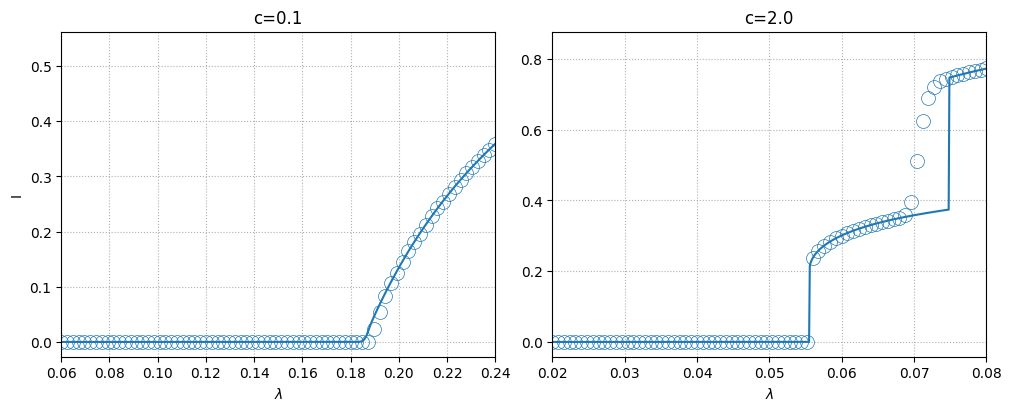

In [172]:
fig, axs = plt.subplots(1, len(c_list), figsize=(5*len(c_list), 4), constrained_layout=True)
if len(c_list) == 1:
    axs = [axs]
for c_idx, c in enumerate(c_list):
    for r_idx, rho in enumerate(rho0_values):
        I = sim_results[c_idx]["I"]
        I_rho = I.sel(rho=rho).mean(dim="itr")/N
        I_rho.plot(ax=axs[c_idx], marker="o", markersize=10, ls="", markerfacecolor="none", markeredgewidth=0.5)
        ame_I=ame_results[c_idx]["I"]
        ame_I.sel(rho=rho).sel(c=c).squeeze().plot(ax=axs[c_idx], color="tab:blue")
    axs[c_idx].set_title(f"c={c}")
    min_lambda = I.sel(c=c)["lambda"].min()
    max_lambda = I.sel(c=c)["lambda"].max()
    axs[c_idx].set_xlim(min_lambda, max_lambda)
    axs[c_idx].grid(True, linestyle=":")
    axs[c_idx].set_xlabel(r"$\lambda$")
    if c_idx == 0:
        axs[c_idx].set_ylabel("I")
    else:
        axs[c_idx].set_ylabel("")
plt.show()
